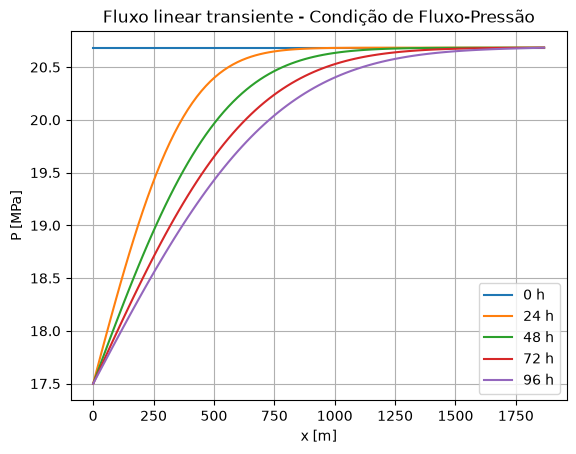

In [1]:
#transient 1D linear solution with conditions pressure-pressure

import numpy as np
import matplotlib.pyplot as plt

from analytical.transiente_L1d_PP import linear_trans_1d_PP

# parameters
Pw = 17.499e6             # pressão em x = 0 [Pa] 
p0 = 20.684e6             # pressão em x = L [Pa] e pressão inicial
A_R = 3484800              # área do reservatório [m²]
L = np.sqrt(A_R)                     # comprimento (considerando um reservatório quadrado) [m]
k = 339*9.869233e-16      # permeabilidade [m²]  =  339 mD
phi = 0.22              # porosidade [-]
ct = 3.046e-9                 # compressibilidade total [1/Pa]
mu = 1.0e-3                  # viscosidade [Pa.s]  =  1 cP
t_h = 96 # tempo [h]
t_final = t_h*3600       # tempo [s]
n_modos = 100

x, t, X, T, P = linear_trans_1d_PP(p0, Pw, L, k, phi, ct, mu, t_final, n_modos)

# P em função de x
tempos_escolhidos = np.linspace(0, t_h, 5)  # horas

for tempo in tempos_escolhidos:

    t_escolhido = tempo * 3600

    indice_t = np.argmin(np.abs(t - t_escolhido))

    plt.plot(x, P[indice_t, :] / 1e6, label=f'{t[indice_t]/3600:.0f} h')

plt.xlabel('x [m]')
plt.ylabel('P [MPa]')
plt.title('Fluxo linear transiente - Condição de Pressão-Pressão')

plt.legend()
plt.grid()
plt.show()